In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.12.1+cpu


In [2]:
df = pd.read_csv("../../Weekend Project/Project 2/loan_default_dataset.csv")

df_clean = df.copy()
df_clean["home_ownership"] = df_clean["home_ownership"].str.upper().str.strip()
df_clean["purpose"] = df_clean["purpose"].str.lower().str.strip()
df_clean.loc[(df_clean["age"] < 18) | (df_clean["age"] > 100), "age"] = np.nan

numeric_cols = [
    "age", "annual_income", "credit_score", "loan_amount",
    "loan_term_months", "interest_rate", "debt_to_income",
    "employment_length_years", "num_open_accounts", "num_late_payments_2yrs"
]
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

df_encoded = pd.get_dummies(df_clean, columns=["home_ownership", "purpose"], dtype=int)

print(f"cleaned and encoded shape: {df_encoded.shape}")

cleaned and encoded shape: (6015, 21)


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

TARGET = "default"
X = df_encoded.drop(columns=[TARGET])
y = df_encoded[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train: {X_train_scaled.shape}")
print(f"X_test : {X_test_scaled.shape}")

X_train: (4812, 20)
X_test : (1203, 20)


In [4]:
X_train_tensor = torch.FloatTensor(X_train_scaled.copy())
y_train_tensor = torch.LongTensor(y_train.values.copy())

X_test_tensor = torch.FloatTensor(X_test_scaled.copy())
y_test_tensor = torch.LongTensor(y_test.values.copy())

print(f"X_train_tensor: {X_train_tensor.shape}")
print(f"X_test_tensor : {X_test_tensor.shape}")

X_train_tensor: torch.Size([4812, 20])
X_test_tensor : torch.Size([1203, 20])


In [5]:
# wrap tensors into a TensorDataset
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# training loader: shuffled mini-batches of 64
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# validation loader: NOT shuffled — order doesn't matter for evaluation
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print(f"number of training batches  : {len(train_loader)}")
print(f"number of validation batches: {len(val_loader)}")

# peek at one batch
sample_X, sample_y = next(iter(train_loader))
print(f"\none batch shape: {sample_X.shape}, labels shape: {sample_y.shape}")

number of training batches  : 76
number of validation batches: 19

one batch shape: torch.Size([64, 20]), labels shape: torch.Size([64])


In [6]:
class LoanDefaultMLP(nn.Module):
    def __init__(self, input_size):
        super(LoanDefaultMLP, self).__init__()
        self.layer1 = nn.Linear(input_size, 32)
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 2)

    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.relu(x)
        x = self.output(x)
        return x

input_size = X_train_tensor.shape[1]
model = LoanDefaultMLP(input_size)
print(model)

LoanDefaultMLP(
  (layer1): Linear(in_features=20, out_features=32, bias=True)
  (relu): ReLU()
  (layer2): Linear(in_features=32, out_features=16, bias=True)
  (output): Linear(in_features=16, out_features=2, bias=True)
)


In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("loss function: CrossEntropyLoss")
print("optimizer: Adam, lr=0.001")

loss function: CrossEntropyLoss
optimizer: Adam, lr=0.001


In [8]:
epochs = 25
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):
    # === TRAINING PHASE ===
    model.train()
    running_train_loss = 0.0

    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * batch_X.size(0)

    avg_train_loss = running_train_loss / len(train_dataset)
    train_loss_history.append(avg_train_loss)

    # === VALIDATION PHASE ===
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            running_val_loss += loss.item() * batch_X.size(0)

    avg_val_loss = running_val_loss / len(val_dataset)
    val_loss_history.append(avg_val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch [1/25] Train Loss: 0.5406 | Val Loss: 0.4262
Epoch [2/25] Train Loss: 0.4074 | Val Loss: 0.3890
Epoch [3/25] Train Loss: 0.3845 | Val Loss: 0.3782
Epoch [4/25] Train Loss: 0.3765 | Val Loss: 0.3763
Epoch [5/25] Train Loss: 0.3722 | Val Loss: 0.3728
Epoch [6/25] Train Loss: 0.3691 | Val Loss: 0.3723
Epoch [7/25] Train Loss: 0.3674 | Val Loss: 0.3721
Epoch [8/25] Train Loss: 0.3658 | Val Loss: 0.3724
Epoch [9/25] Train Loss: 0.3641 | Val Loss: 0.3724
Epoch [10/25] Train Loss: 0.3626 | Val Loss: 0.3719
Epoch [11/25] Train Loss: 0.3612 | Val Loss: 0.3707
Epoch [12/25] Train Loss: 0.3603 | Val Loss: 0.3728
Epoch [13/25] Train Loss: 0.3587 | Val Loss: 0.3725
Epoch [14/25] Train Loss: 0.3590 | Val Loss: 0.3724
Epoch [15/25] Train Loss: 0.3573 | Val Loss: 0.3711
Epoch [16/25] Train Loss: 0.3561 | Val Loss: 0.3713
Epoch [17/25] Train Loss: 0.3558 | Val Loss: 0.3705
Epoch [18/25] Train Loss: 0.3544 | Val Loss: 0.3722
Epoch [19/25] Train Loss: 0.3541 | Val Loss: 0.3715
Epoch [20/25] Train L

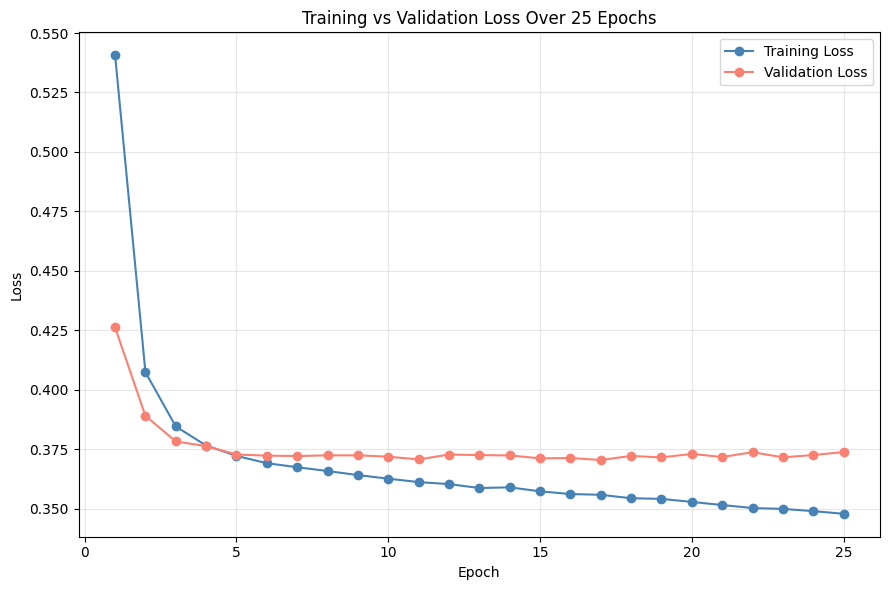

loss curves saved


In [9]:
plt.figure(figsize=(9, 6))
plt.plot(range(1, epochs+1), train_loss_history, label="Training Loss", color="steelblue", marker="o")
plt.plot(range(1, epochs+1), val_loss_history, label="Validation Loss", color="salmon", marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss Over 25 Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("train_val_loss_curve.png")
plt.show()
print("loss curves saved")

In [10]:
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    _, predicted = torch.max(test_outputs, 1)
    accuracy = (predicted == y_test_tensor).float().mean()

print(f"Final Test Accuracy: {accuracy.item():.4f}")

Final Test Accuracy: 0.8346


In [11]:
explanation = """
=== WHY ADAM IS BETTER THAN SGD ===

SGD:
- Uses one fixed learning rate for all parameters.
- Works well but struggles with sparse features.

Adam:
- Uses momentum (m_t) and adaptive learning rates (v_t).
- Adjusts updates for each parameter individually.
- Small gradients get larger updates, while noisy ones are reduced.

Momentum also helps Adam move through flat or saddle regions,
where SGD may slow down or stop.

Result:
Adam converges faster and produces a smoother loss curve,
making it a better choice for sparse one-hot encoded data.
"""
print(explanation)


=== WHY ADAM IS BETTER THAN SGD ===

SGD:
- Uses one fixed learning rate for all parameters.
- Works well but struggles with sparse features.

Adam:
- Uses momentum (m_t) and adaptive learning rates (v_t).
- Adjusts updates for each parameter individually.
- Small gradients get larger updates, while noisy ones are reduced.

Momentum also helps Adam move through flat or saddle regions,
where SGD may slow down or stop.

Result:
Adam converges faster and produces a smoother loss curve,
making it a better choice for sparse one-hot encoded data.



In [12]:
batch_explanation = """
=== WHY MINI-BATCHES ARE USEFUL ===

Without mini-batches:
- The entire dataset is loaded into memory at once,
  which can cause high RAM usage or out-of-memory errors.

With mini-batches:
- Only a small batch (e.g., 64 samples) is processed at a time.
- After updating the model, that batch is removed from memory
  before the next one is loaded.

Benefits:
- Keeps memory usage low and stable.
- Works efficiently even with very large datasets.
- The small randomness in batches also helps the model
  learn better and avoid overfitting.
"""
print(batch_explanation)


=== WHY MINI-BATCHES ARE USEFUL ===

Without mini-batches:
- The entire dataset is loaded into memory at once,
  which can cause high RAM usage or out-of-memory errors.

With mini-batches:
- Only a small batch (e.g., 64 samples) is processed at a time.
- After updating the model, that batch is removed from memory
  before the next one is loaded.

Benefits:
- Keeps memory usage low and stable.
- Works efficiently even with very large datasets.
- The small randomness in batches also helps the model
  learn better and avoid overfitting.

